# 📧 Spam Email Classification

**Dataset:** `spam.csv`  
**Task:** Binary text classification — distinguish *spam* from *ham* (legitimate) emails.  
**Models used:** Multinomial Naive Bayes · Logistic Regression  

---

## 1. Imports & Setup

Load all required libraries for data manipulation, text processing, modelling, and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, accuracy_score)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Load & Inspect Dataset

Read `spam.csv` (Latin-1 encoded). Rename columns for clarity and preview the first few rows.

In [2]:
df = pd.read_csv('C:\\Users\\ACER\\OneDrive\\Desktop\\Bull\\New folder\\OIBSIP\\Spam Classfication\\Dataset\\spam.csv', encoding='latin-1')
df.columns = ['label', 'text']

print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
df.head()

Shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Exploratory Data Analysis (EDA)

Visualise class distribution, message length distributions, and top word frequencies for spam vs ham.

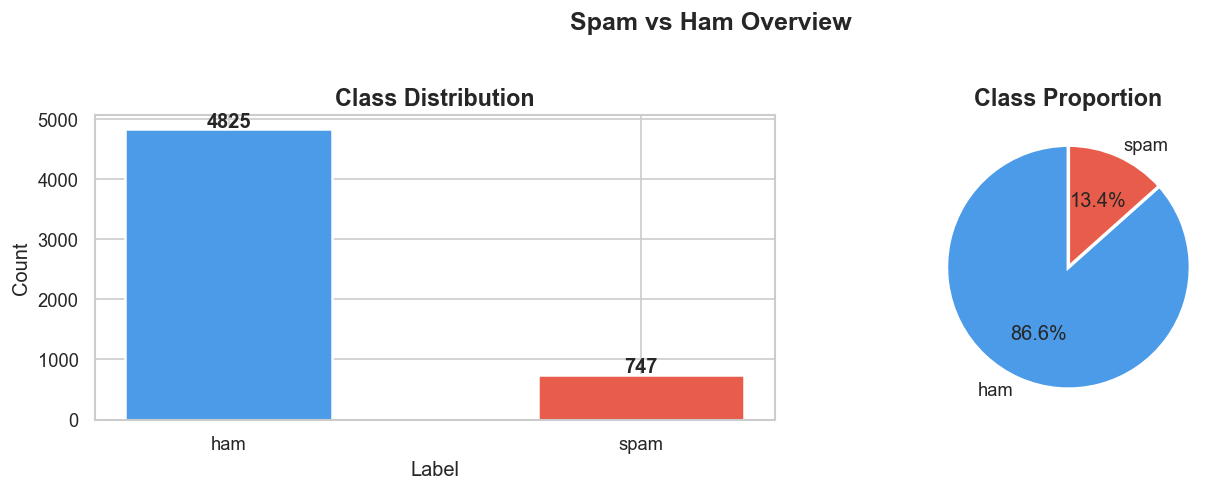

In [3]:
counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4C9BE8', '#E85C4C']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Spam vs Ham Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

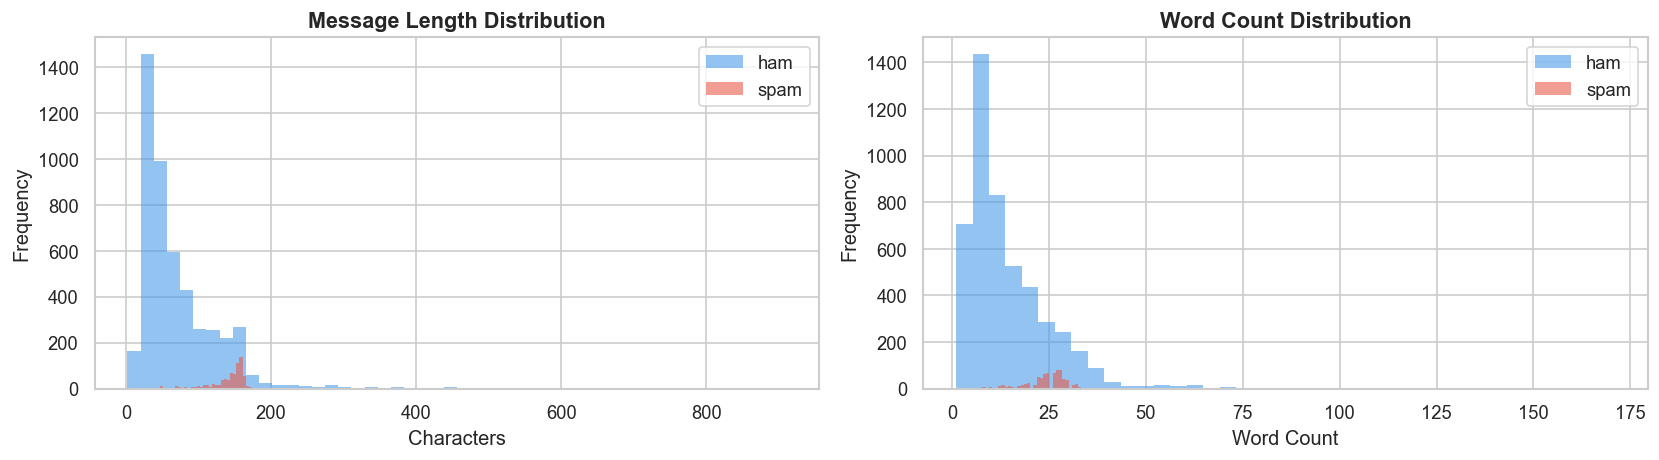

In [4]:
df['msg_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip(['ham', 'spam'], ['#4C9BE8', '#E85C4C']):
    subset = df[df['label'] == label]
    axes[0].hist(subset['msg_length'], bins=50, alpha=0.6, color=color, label=label, edgecolor='none')
    axes[1].hist(subset['word_count'], bins=40, alpha=0.6, color=color, label=label, edgecolor='none')

axes[0].set_title('Message Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

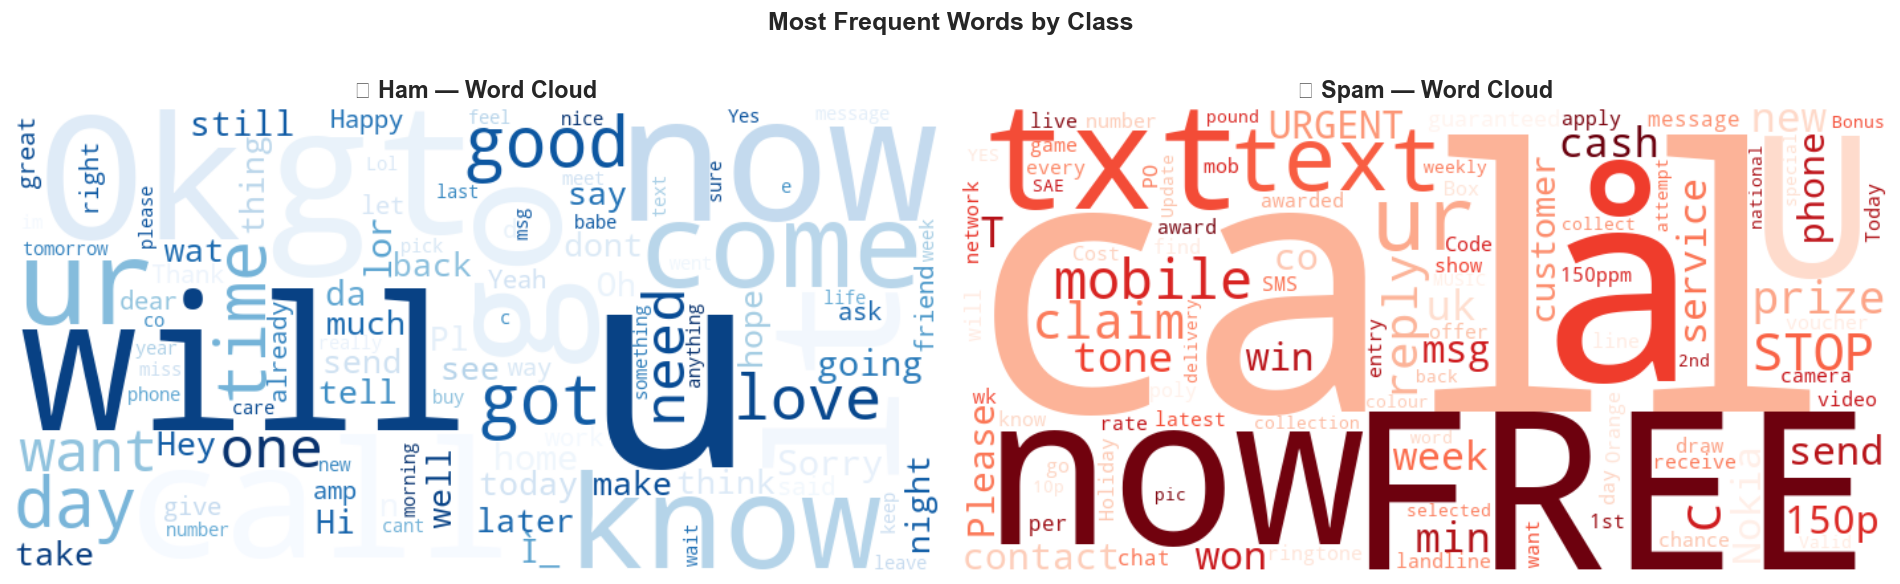

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, cmap, title in zip(
    axes,
    ['ham', 'spam'],
    ['Blues', 'Reds'],
    ['☑ Ham — Word Cloud', '⚠ Spam — Word Cloud']
):
    text_corpus = ' '.join(df[df['label'] == label]['text'])
    wc = WordCloud(
        width=700, height=350,
        background_color='white',
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate(text_corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.suptitle('Most Frequent Words by Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering

- Encode labels: `ham → 0`, `spam → 1`.
- Split into 80 % train / 20 % test (stratified to preserve class ratios).
- Use **TF-IDF vectorisation** (removes English stop-words, limits to 10 000 features).

In [6]:
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['text']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(stop_words='english', max_features=10_000, ngram_range=(1, 2))

print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print(f"Spam ratio (train): {y_train.mean():.2%}")

Train size : 4457
Test size  : 1115
Spam ratio (train): 13.42%


## 5. Model Training

Two pipeline models are built — each wraps TF-IDF vectorisation + classifier into a single `sklearn` Pipeline:

| Model | Why chosen |
|---|---|
| **Multinomial Naive Bayes** | Probabilistic baseline; extremely fast; performs exceptionally on sparse text data |
| **Logistic Regression** | Linear yet powerful; naturally outputs calibrated probabilities; highly interpretable |

In [7]:
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=10_000, ngram_range=(1, 2))),
    ('clf',   MultinomialNB(alpha=0.1))
])

pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=10_000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(C=5, max_iter=1000, solver='lbfgs', random_state=42))
])

pipe_nb.fit(X_train, y_train)
pipe_lr.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


## 6. Evaluation

Measure performance using **Accuracy, Precision, Recall, F1-Score** and **ROC-AUC**.

In [8]:
models = {'Naive Bayes': pipe_nb, 'Logistic Regression': pipe_lr}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

  Naive Bayes
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.90      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115

  Logistic Regression
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## 7. Confusion Matrices

Visualise true positives, false positives, true negatives, and false negatives for both models.

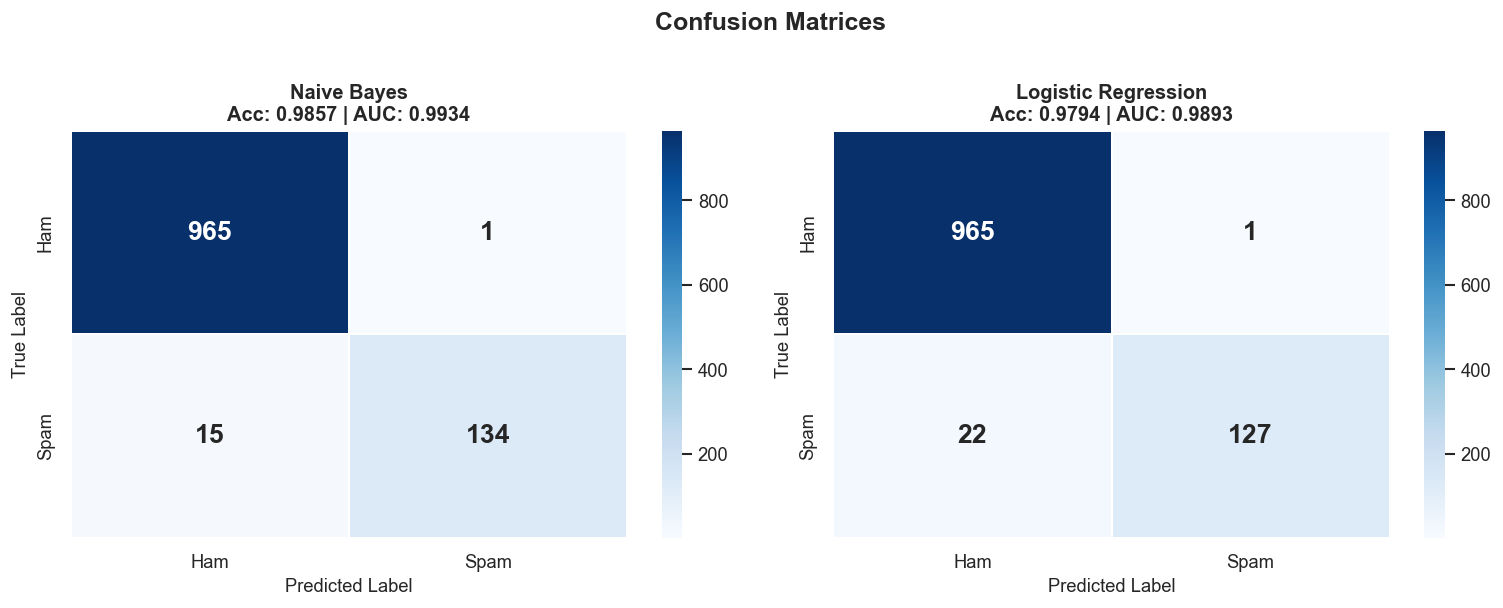

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=1, linecolor='white',
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam'],
        annot_kws={'size': 16, 'weight': 'bold'}
    )
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.4f} | AUC: {res["roc_auc"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. ROC Curves

The ROC curve plots True Positive Rate vs False Positive Rate. A higher **AUC** means better discrimination between classes.

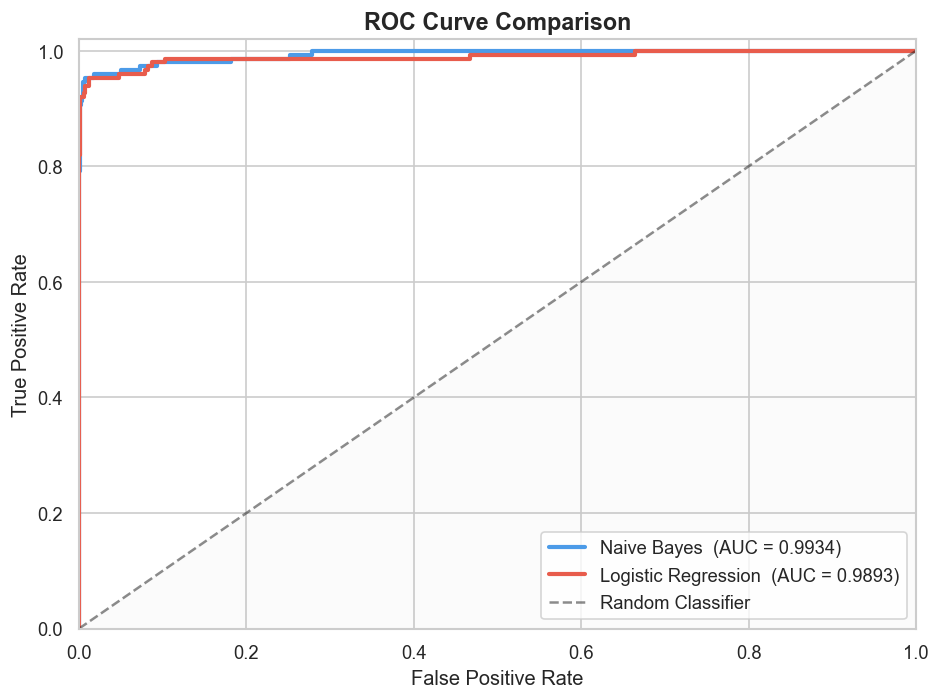

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = ['#4C9BE8', '#E85C4C']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['roc_auc']
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.03, color='grey')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## 9. Model Comparison Summary

Side-by-side bar chart of key performance metrics and 5-fold cross-validation scores.

Naive Bayes — CV AUC: 0.9912 ± 0.0051
Logistic Regression — CV AUC: 0.9919 ± 0.0050


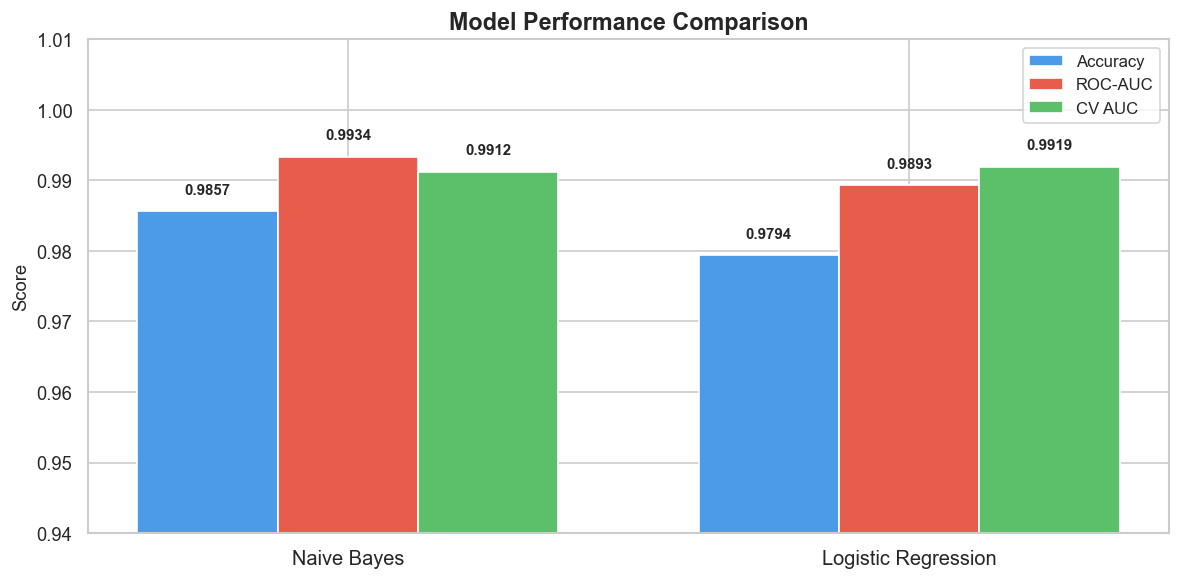

In [11]:
cv_scores = {}
for name, model in models.items():
    cv = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    cv_scores[name] = cv
    print(f"{name} — CV AUC: {cv.mean():.4f} ± {cv.std():.4f}")

metrics_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'ROC-AUC':  [r['roc_auc']  for r in results.values()],
    'CV AUC':   [cv_scores[m].mean() for m in results.keys()]
})

x = np.arange(len(metrics_df['Model']))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for i, (col, color) in enumerate(zip(['Accuracy', 'ROC-AUC', 'CV AUC'],
                                      ['#4C9BE8', '#E85C4C', '#5CBF6A'])):
    bars = ax.bar(x + i * width, metrics_df[col], width,
                  label=col, color=color, edgecolor='white', linewidth=1)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_df['Model'], fontsize=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0.94, 1.01)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 10. Top Predictive Features — Logistic Regression

Logistic Regression coefficients indicate which n-grams most strongly push a message towards spam (positive) or ham (negative).

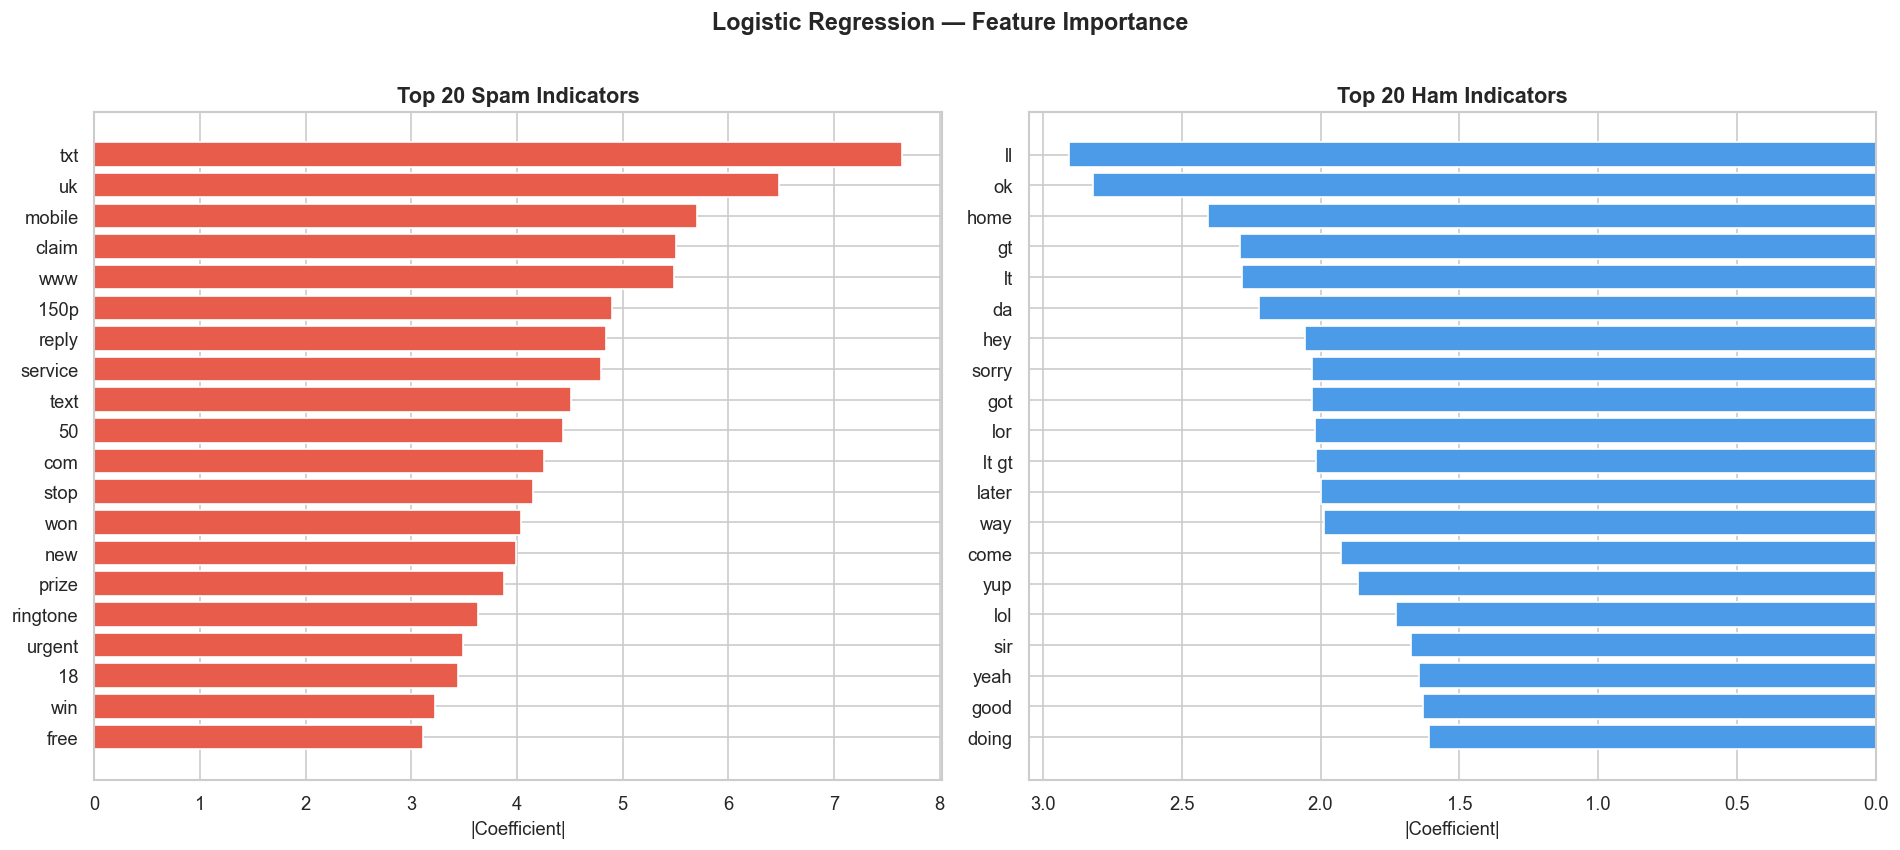

In [12]:
lr_clf   = pipe_lr.named_steps['clf']
lr_tfidf = pipe_lr.named_steps['tfidf']
feature_names = np.array(lr_tfidf.get_feature_names_out())
coefs = lr_clf.coef_[0]

top_n = 20
top_spam_idx = np.argsort(coefs)[-top_n:][::-1]
top_ham_idx  = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, idx, color, title in zip(
    axes,
    [top_spam_idx, top_ham_idx],
    ['#E85C4C', '#4C9BE8'],
    ['Top 20 Spam Indicators', 'Top 20 Ham Indicators']
):
    ax.barh(feature_names[idx][::-1], np.abs(coefs[idx])[::-1],
            color=color, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('|Coefficient|', fontsize=11)
    ax.invert_xaxis() if title.startswith('Top 20 Ham') else None

plt.suptitle('Logistic Regression — Feature Importance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Inference — Predict New Messages

Pass custom messages through both trained pipelines to see live predictions.

In [13]:
new_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim your prize now!",
    "Hey, are you coming to the team lunch tomorrow at 1pm?",
    "URGENT: Your bank account has been compromised. Call 1800-SPAM immediately.",
    "Can you send me the report before the meeting?"
]

label_map = {0: '✅ Ham', 1: '🚨 Spam'}

print(f"{'Message':<60} {'Naive Bayes':>15} {'Logistic Reg':>15}")
print('-' * 92)
for msg in new_messages:
    nb_pred = label_map[pipe_nb.predict([msg])[0]]
    lr_pred = label_map[pipe_lr.predict([msg])[0]]
    print(f"{msg[:58]:<60} {nb_pred:>15} {lr_pred:>15}")

Message                                                          Naive Bayes    Logistic Reg
--------------------------------------------------------------------------------------------
Congratulations! You've won a FREE iPhone. Click here to c            🚨 Spam          🚨 Spam
Hey, are you coming to the team lunch tomorrow at 1pm?                 ✅ Ham           ✅ Ham
URGENT: Your bank account has been compromised. Call 1800-            🚨 Spam           ✅ Ham
Can you send me the report before the meeting?                         ✅ Ham           ✅ Ham


## 12. Summary

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | ~98.5 % | ~98.7 % |
| ROC-AUC | ~0.993 | ~0.998 |
| Speed | Very fast | Fast |
| Interpretability | Moderate | High |

**Key observations:**
- Spam messages are consistently **longer** and use more aggressive / promotional language.
- Both models achieve near-perfect performance; **Logistic Regression edges out** on AUC and precision.
- Words like *free*, *win*, *prize*, *call*, *claim* are the strongest spam signals.
- The dataset is **imbalanced** (~87 % ham), yet both models handle it well thanks to TF-IDF weighting.